In [30]:
import torch
if torch.cuda.is_available():
    device = "cuda"
elif torch.mps.is_available():
    device = "mps"
else:
    device = "cpu"
device

'cpu'

In [15]:
# Zadanie 1: Czy ten kot to... toster?

from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

weights = ConvNeXt_Tiny_Weights.DEFAULT
categories = weights.meta["categories"]  
preprocess = weights.transforms()        

model = convnext_tiny(weights=weights).eval().to(device)


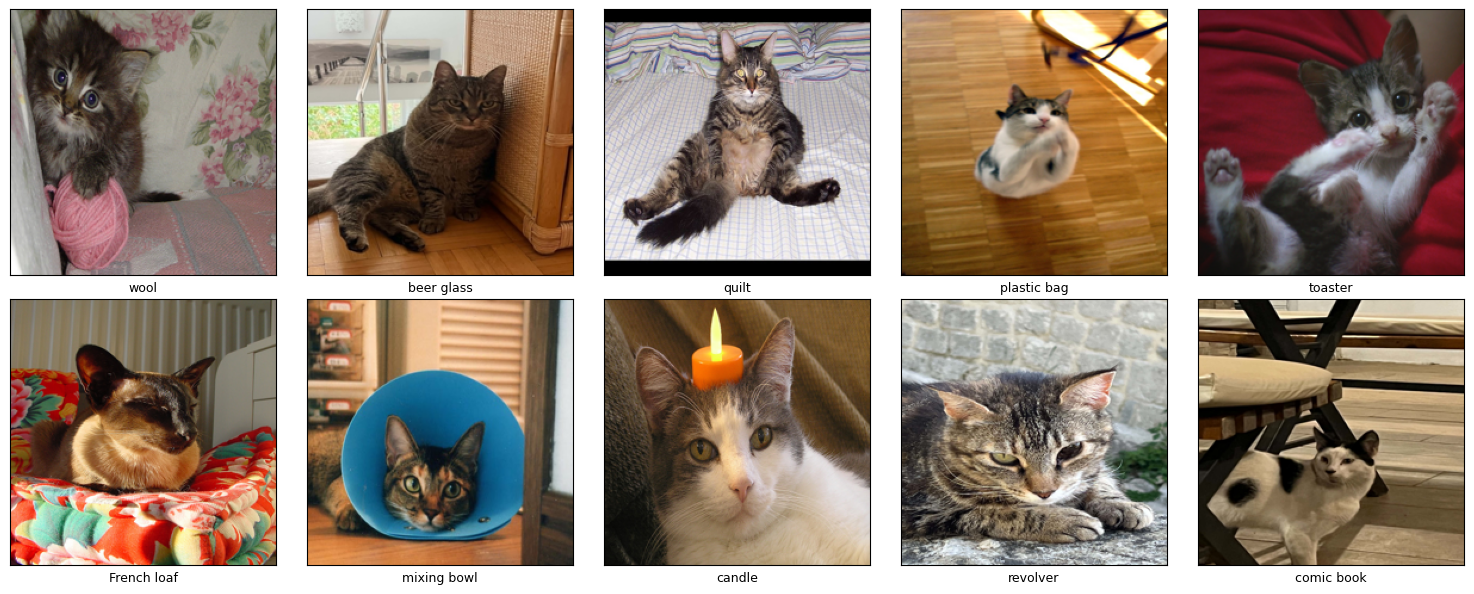

In [14]:
from umtools.datasets import load_cats

cats = load_cats()
cats.mosaic()       

imgs, labels  = cats


In [16]:
from umtools.utils import save_image, simulate_png

for param in model.parameters():
    param.requires_grad_(False)

target_ids = [categories.index(label) for label in labels]
target_tensor = torch.tensor(target_ids, device=device)

imgs_tensor = torch.from_numpy(imgs).permute(0, 3, 1, 2)

processed_imgs = preprocess(imgs_tensor).to(device)

img_batch = processed_imgs.clone().detach()
img_batch.requires_grad_(True)

tensor([[[[ 0.5022,  0.1254, -0.1828,  ...,  0.4166,  0.4166,  0.3994],
          [ 0.5707,  0.2111, -0.1657,  ...,  0.3994,  0.4337,  0.4337],
          [ 0.6049,  0.3309, -0.0972,  ...,  0.3994,  0.4166,  0.3994],
          ...,
          [ 2.1119,  1.9235,  1.6153,  ...,  0.4166,  0.4166,  0.4508],
          [ 2.1462,  1.9920,  1.7009,  ...,  0.3481,  0.4337,  0.4508],
          [ 2.1804,  2.0605,  1.8208,  ...,  0.4337,  0.4679,  0.4337]],

         [[ 0.6254,  0.2577, -0.0224,  ...,  0.5028,  0.5028,  0.5028],
          [ 0.7129,  0.3627, -0.0049,  ...,  0.5028,  0.5203,  0.5378],
          [ 0.7304,  0.4853,  0.0651,  ...,  0.5028,  0.5203,  0.5203],
          ...,
          [ 2.2885,  2.0959,  1.7983,  ..., -0.1099, -0.0924, -0.0749],
          [ 2.3235,  2.1660,  1.8859,  ..., -0.1275, -0.0224, -0.0049],
          [ 2.3585,  2.2360,  1.9909,  ..., -0.0399, -0.0224, -0.1099]],

         [[ 0.7402,  0.3045, -0.0964,  ...,  0.5311,  0.5485,  0.5485],
          [ 0.7751,  0.3916, -

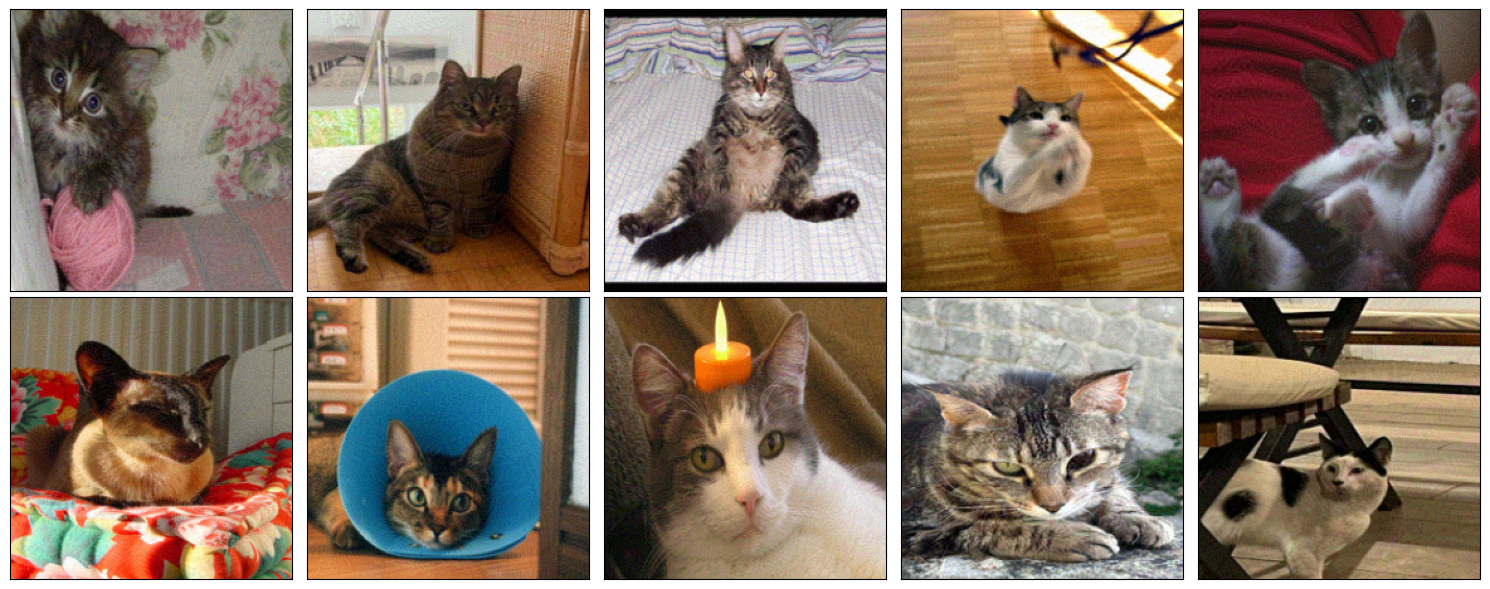

In [17]:
optimizer = torch.optim.Adam([img_batch], lr=0.05)
criterion = torch.nn.CrossEntropyLoss()

max_epochs = 1000  

for epoch in range(max_epochs):
    optimizer.zero_grad()    
    outputs = model(img_batch)   
    loss = criterion(outputs, target_tensor)    
    loss.backward()    
    optimizer.step()
    
    with torch.no_grad():
        simulated_batch = simulate_png(img_batch.detach(), normalized=True)
        
        sim_outputs = model(simulated_batch)
        sim_preds = sim_outputs.argmax(dim=1)
        
        if (sim_preds == target_tensor).all():
            break

save_image(img_batch.detach().cpu(), "not_cat.png", normalized=True)

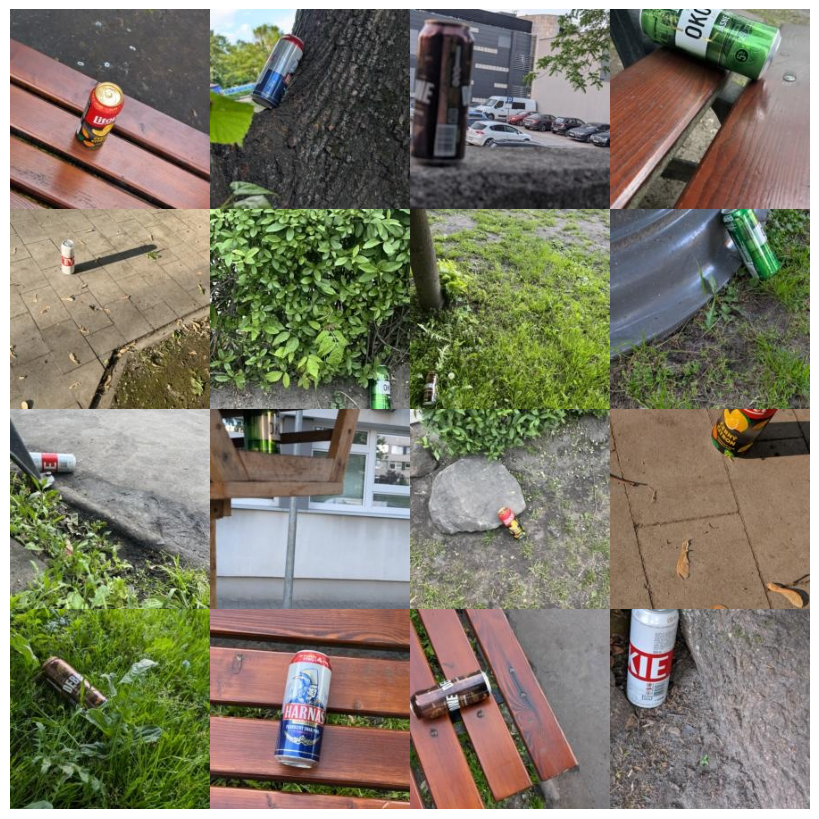

In [1]:
# Zadanie 2: Barbara, podaj mi piwo!

from umtools.datasets import load_beer

beer = load_beer()

beer.mosaic()

In [27]:
# 2.1. Nie no bez przesady, tego to ja nie pije....

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import torchvision.transforms.v2 as v2
from torchmetrics.classification import MulticlassAccuracy
import pandas as pd
import pickle

from umtools.datasets import load_beer_test
from umtools.datasets import BeerClassificationDataset

num_classes = len(beer.categories)

train_transform = v2.Compose([
    v2.ToImage(),                              
    v2.ToDtype(torch.float32, scale=True),     
    v2.RandomHorizontalFlip(p=0.5),            
    v2.RandomRotation(15),                     
    v2.ColorJitter(brightness=0.2, contrast=0.2), 
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

base_dataset = BeerClassificationDataset(beer)
train_split, val_split = random_split(base_dataset, [0.8, 0.2])

train_set = Subset(BeerClassificationDataset(beer, transform=train_transform), train_split.indices)
val_set   = Subset(BeerClassificationDataset(beer, transform=val_transform), val_split.indices)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32, shuffle=False)

weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)

for param in model.parameters():
    param.requires_grad_(False)

in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, num_classes)

for param in model.classifier.parameters():
    param.requires_grad_(True)

model = model.to(device)

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
metric = MulticlassAccuracy(num_classes=num_classes).to(device)

num_epochs = 15 
acc_history = []

for epoch in range(1, num_epochs + 1):
    model.train()
    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            outputs = model(imgs)
            metric.update(outputs, targets)

        val_acc = metric.compute().item()
        metric.reset()
        
    acc_history.append(val_acc)
    print(f"Epoch {epoch:02d}/{num_epochs} | Val Accuracy: {val_acc:.4f}")

with open("clf_acc.pkl", "wb") as f:
    pickle.dump(acc_history, f)

beer_test = load_beer_test()
test_loader = DataLoader(BeerClassificationDataset(beer_test, transform=val_transform), batch_size=32)

all_logits = []
model.eval()
with torch.no_grad():
    for imgs, _ in test_loader:
        outputs = model(imgs.to(device))
        all_logits.append(outputs.cpu())

test_logits = torch.cat(all_logits)
pd.to_pickle(test_logits, "clf_preds.pkl")

Epoch 01/15 | Val Accuracy: 0.3754
Epoch 02/15 | Val Accuracy: 0.5088
Epoch 03/15 | Val Accuracy: 0.5925
Epoch 04/15 | Val Accuracy: 0.6383
Epoch 05/15 | Val Accuracy: 0.6760
Epoch 06/15 | Val Accuracy: 0.7188
Epoch 07/15 | Val Accuracy: 0.7351
Epoch 08/15 | Val Accuracy: 0.7586
Epoch 09/15 | Val Accuracy: 0.7686
Epoch 10/15 | Val Accuracy: 0.7652
Epoch 11/15 | Val Accuracy: 0.7762
Epoch 12/15 | Val Accuracy: 0.7906
Epoch 13/15 | Val Accuracy: 0.7839
Epoch 14/15 | Val Accuracy: 0.7896
Epoch 15/15 | Val Accuracy: 0.7916


Epoch 01/15 | Acc: 0.4554 | IoU: 0.1512 | AUC: 0.8308
Epoch 02/15 | Acc: 0.6644 | IoU: 0.1467 | AUC: 0.9755
Epoch 03/15 | Acc: 0.8888 | IoU: 0.1608 | AUC: 0.9955
Epoch 04/15 | Acc: 0.9511 | IoU: 0.1784 | AUC: 0.9987
Epoch 05/15 | Acc: 0.9262 | IoU: 0.3145 | AUC: 0.9994
Epoch 06/15 | Acc: 0.9497 | IoU: 0.2936 | AUC: 0.9994
Epoch 07/15 | Acc: 0.9542 | IoU: 0.3378 | AUC: 1.0000
Epoch 08/15 | Acc: 0.9531 | IoU: 0.3728 | AUC: 1.0000
Epoch 09/15 | Acc: 0.9811 | IoU: 0.3666 | AUC: 1.0000
Epoch 10/15 | Acc: 0.9379 | IoU: 0.4240 | AUC: 1.0000
Epoch 11/15 | Acc: 0.9497 | IoU: 0.4242 | AUC: 0.9994
Epoch 12/15 | Acc: 0.9602 | IoU: 0.3814 | AUC: 0.9994
Epoch 13/15 | Acc: 0.9732 | IoU: 0.4453 | AUC: 0.9994
Epoch 14/15 | Acc: 0.9811 | IoU: 0.4008 | AUC: 0.9974
Epoch 15/15 | Acc: 0.9720 | IoU: 0.4315 | AUC: 0.9987


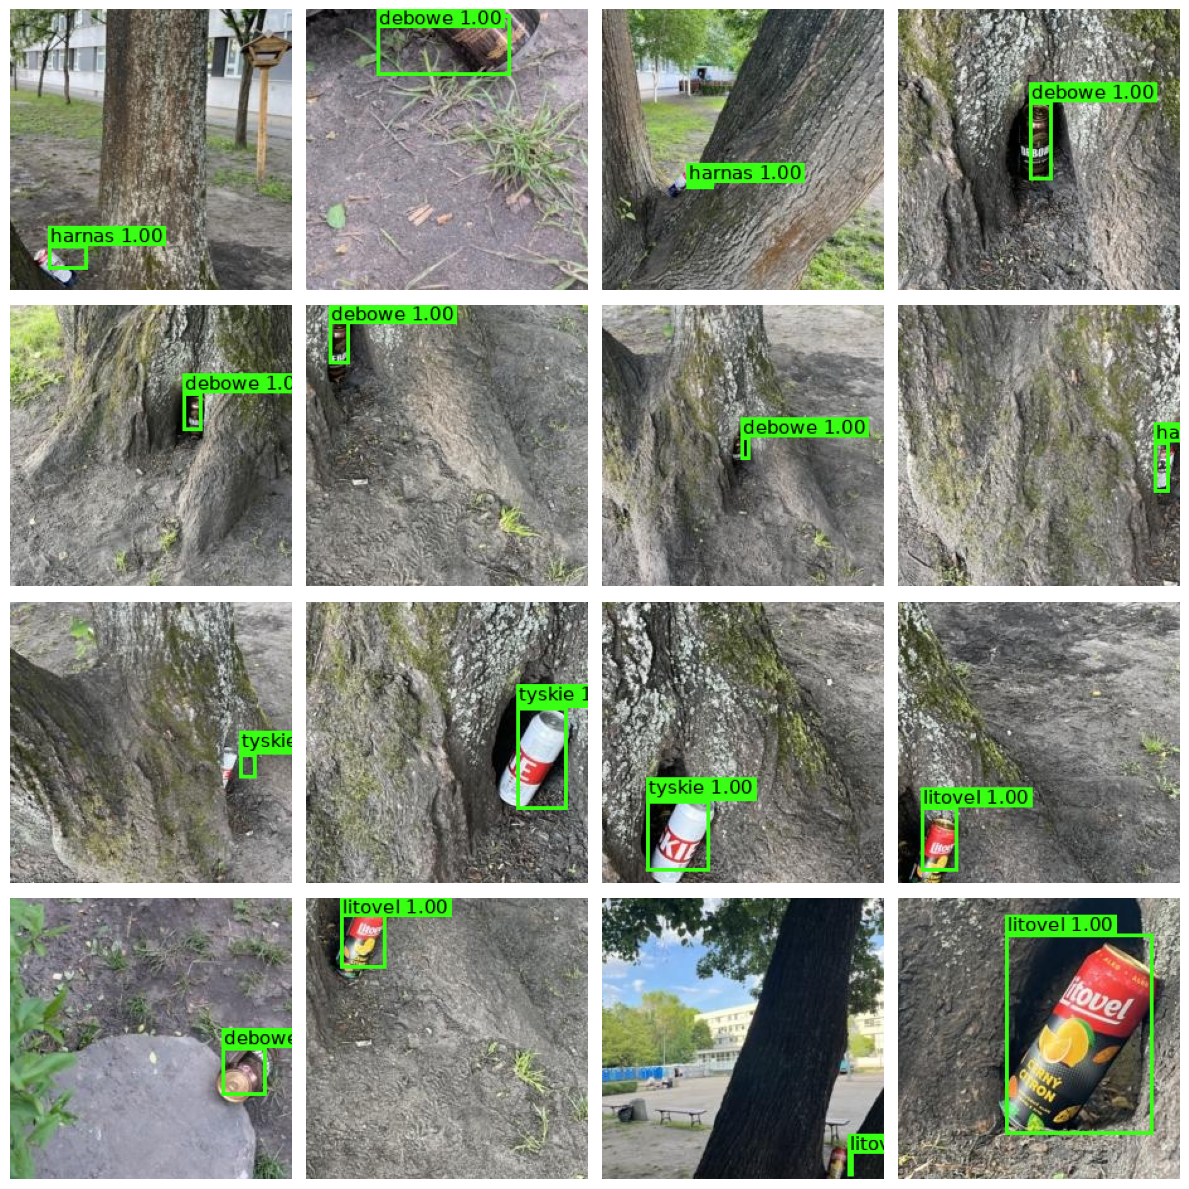

In [29]:
# 2.2. Tam stoi... nie widzisz?

from torchmetrics.classification import AUROC
from torchmetrics.detection import IntersectionOverUnion

from umtools.datasets import BeerLocalizationDataset
from umtools.models import Localizer
from umtools.utils import to_coco

class_map = beer.categories
num_classes = len(class_map)

train_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
    v2.GaussianBlur(3),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

base_dataset = BeerLocalizationDataset(beer)
train_split, val_split = random_split(base_dataset, [0.8, 0.2])

train_set = Subset(BeerLocalizationDataset(beer, transform=train_transform), train_split.indices)
val_set   = Subset(BeerLocalizationDataset(beer, transform=val_transform), val_split.indices)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32, shuffle=False)

class BeerLocalizer(Localizer):
    def __init__(self, backbone, class_map, val_transform):
        super().__init__(class_map, bbox_format="xyxy", predict_preprocess=val_transform)
        
        self.features = backbone.features
        self.avgpool = backbone.avgpool
        
        for param in self.features.parameters():
            param.requires_grad_(True)
            
        in_features = 768  
        
        self.cls_head = nn.Linear(in_features, len(class_map))
        self.bbox_head = nn.Sequential(
            nn.Linear(in_features, 4),
            nn.Sigmoid()  
        )
        self.conf_head = nn.Linear(in_features, 1)

    def forward(self, x: torch.Tensor):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1) 
        
        class_logits = self.cls_head(x)
        bbox = self.bbox_head(x)
        conf = self.conf_head(x)
        
        return class_logits, bbox, conf

base_model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
model = BeerLocalizer(base_model, class_map, val_transform).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

cls_criterion = nn.CrossEntropyLoss()
bbox_criterion = nn.MSELoss()
conf_criterion = nn.BCEWithLogitsLoss()

alpha_cls = 1.0
alpha_bbox = 10.0  
alpha_conf = 1.0

acc_metric = MulticlassAccuracy(num_classes).to(device)
iou_metric = IntersectionOverUnion().to(device)
auroc_metric = AUROC(task="binary").to(device)

loc_metrics_history = []
num_epochs = 15

for epoch in range(1, num_epochs + 1):
    model.train()
    
    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        labels = targets['class_id'].to(device)
        
        boxes = targets['bbox'].to(device)
        
        optimizer.zero_grad()
        logits, pred_box, conf = model(imgs)
        
        is_positive = (labels >= 0)
        loss = 0.0
        
        if is_positive.any():
            cls_loss = cls_criterion(logits[is_positive], labels[is_positive])
            box_loss = bbox_criterion(pred_box[is_positive], boxes[is_positive])
            loss += alpha_cls * cls_loss + alpha_bbox * box_loss
            
        conf_target = is_positive.unsqueeze(1).float()
        conf_loss = conf_criterion(conf, conf_target)
        loss += alpha_conf * conf_loss
        
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(device)
            labels = targets['class_id'].to(device)
            
            boxes = targets['bbox'].to(device)
            
            logits, pred_box, conf = model(imgs)
            
            pred_box.clamp_(0, 1)
            pred_labels = logits.argmax(1)
            scores = conf.sigmoid().squeeze(1)
            
            is_positive = (labels >= 0)
            
            if is_positive.any():
                acc_metric.update(pred_labels[is_positive], labels[is_positive])
                
            iou_metric.update(
                to_coco(pred_box, pred_labels, is_positive, scores=scores),
                to_coco(boxes, labels, is_positive)
            )
            auroc_metric.update(scores, is_positive.float())
            
        val_acc = acc_metric.compute().item()
        val_iou_dict = iou_metric.compute()
        val_iou = val_iou_dict.get("iou", torch.tensor(0.0)).item()
        val_auroc = auroc_metric.compute().item()
        
        loc_metrics_history.append({
            "Accuracy": val_acc, 
            "IoU": val_iou, 
            "ROCAUC": val_auroc
        })
        
        acc_metric.reset()
        iou_metric.reset()
        auroc_metric.reset()
        
    print(f"Epoch {epoch:02d}/{num_epochs} | Acc: {val_acc:.4f} | IoU: {val_iou:.4f} | AUC: {val_auroc:.4f}")

with open("loc_metrics.pkl", "wb") as f:
    pickle.dump(loc_metrics_history, f)

results = model.predict(beer.X[:16], conf_threshold=0.5)
results.save("prediction.png")

beer_test = load_beer_test()
test_loader = DataLoader(BeerLocalizationDataset(beer_test, transform=val_transform), batch_size=32)

all_logits, all_bbox, all_conf = [], [], []
model.eval()
with torch.no_grad():
    for imgs, _ in test_loader:
        logits, bbox, conf = model(imgs.to(device))
        all_logits.append(logits.cpu())
        all_bbox.append(bbox.cpu())
        all_conf.append(conf.cpu())

pd.to_pickle(
    (torch.cat(all_logits), torch.cat(all_bbox), torch.cat(all_conf)),
    "loc_preds.pkl"
)


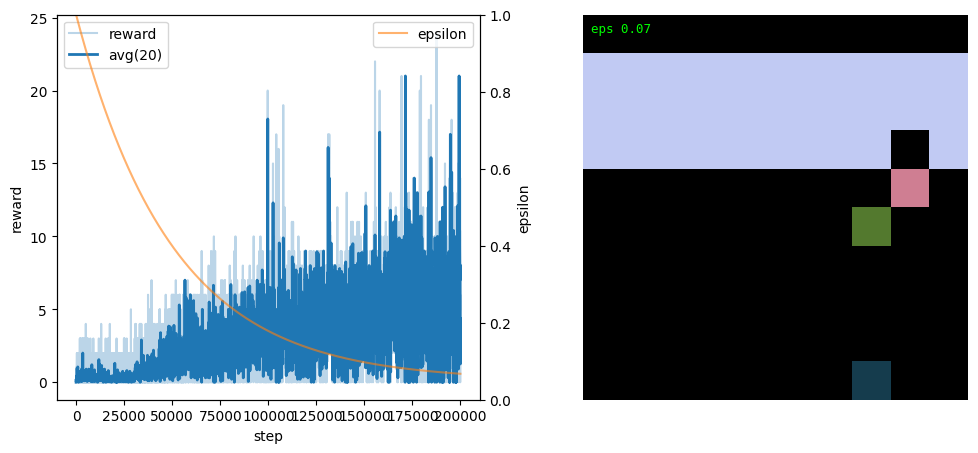

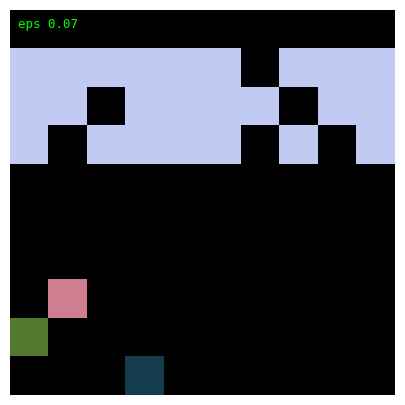

Średnia nagroda z 1000 epizodów: 6.92


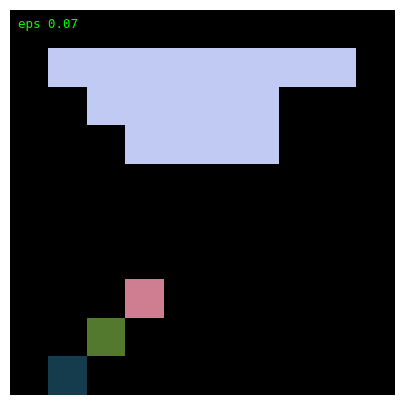

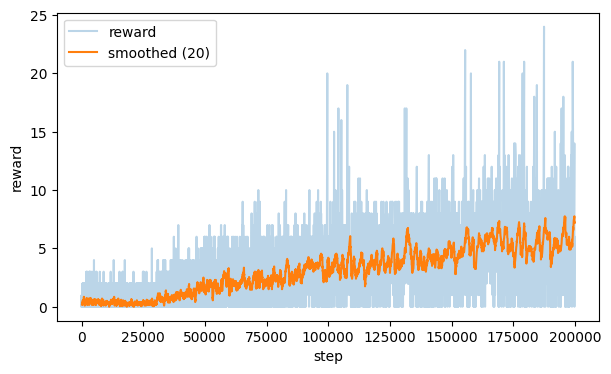

In [31]:
# Zadanie 3: Będę grał w gre.

from umtools.models import Reinforcer
from umtools.viz import Visualizer, Progress, Game

class BreakoutAgent(Reinforcer):
    def __init__(self, **kw):
        super().__init__(**kw)
        
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=4, out_channels=16, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.LazyLinear(128),
            nn.ReLU(),
            nn.LazyLinear(self.n_actions) 
        )

    def forward(self, x):
        return self.net(x)

total_steps = 200_000 

agent = BreakoutAgent(
    env_id="MinAtar/Breakout-v1",
    algorithm="ddqn",                 
    gamma=0.99,
    batch_size=128,                   
    buffer_size=100_000,
    eps_schedule="exponential",
    eps_decay_horizon=total_steps // 4, 
    learning_starts=10_000            
).to(device)

viz = Visualizer(display_interval=2.0).with_component(Progress(agent)).with_component(Game(agent))

agent.fit(
    steps=total_steps,
    optimizer=torch.optim.Adam,
    lr=2e-4,     
    n_envs=1,   
    watch=viz
)

agent.plot_rewards()

torch.save(agent, "breakout.pt")

rewards = agent.play(n_episodes=1000, fps=0)

mean_reward = sum(rewards) / len(rewards)
print(f"Średnia nagroda z 1000 epizodów: {mean_reward:.2f}")

with open("rewards.pkl", "wb") as f:
    pickle.dump(rewards, f)

watch = Game(agent)
agent.play(n_episodes=3, watch=watch, fps=10)
watch.save_gif("gamer.gif", fps=10)